In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("..\data\RawData\Timeseries.csv")

In [4]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 27.9 MB


In [6]:
df.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [7]:
df["date"] = pd.to_datetime(df["date"])

In [8]:
df = df.sort_values(["store","item","date"])

In [9]:
lags = [1,7,14,28]

for lag in lags:
    df[f"lag_{lag}"] = df.groupby(["store","item"])["sales"].shift(lag)

In [10]:
windows = [7,14,28]

for w in windows:
    df[f"rolling_mean_{w}"] = (
        df.groupby(["store","item"])["sales"].shift(1)
    .rolling(w).mean()
    )

    
for w in windows:
    df[f"rolling_std_{w}"] = (
        df.groupby(["store","item"])["sales"].shift(1)
        .rolling(w).std()
    )

In [11]:
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["week"] = df["date"].dt.isocalendar().week.astype(int)

In [12]:
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

In [13]:
df["trend"] = df.groupby(["store", "item"]).cumcount()

In [14]:
df["diff_1"] = df.groupby(["store", "item"])["sales"].diff(1)
df["diff_7"] = df.groupby(["store", "item"])["sales"].diff(7)

df["roc_7"] = df.groupby(["store", "item"])["sales"].pct_change(7)

In [15]:
# Store-level average
df["store_avg_sales"] = df.groupby("store")["sales"].transform("mean")

# Item-level average
df["item_avg_sales"] = df.groupby("item")["sales"].transform("mean")

In [16]:
df = df.dropna()

In [17]:
df.head()

,date,store,item,sales,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,...,dow_sin,dow_cos,month_sin,month_cos,trend,diff_1,diff_7,roc_7,store_avg_sales,item_avg_sales
28,2013-01-29,1,1,6,11.0,7.0,5.0,13.0,10.428571,10.642857,...,0.781831,0.623490,0.500000,0.866025,28,-5.0,-1.0,-0.142857,47.268379,21.981599
29,2013-01-30,1,1,9,6.0,9.0,7.0,11.0,10.285714,10.714286,...,0.974928,-0.222521,0.500000,0.866025,29,3.0,0.0,0.000000,47.268379,21.981599
30,2013-01-31,1,1,13,9.0,8.0,16.0,14.0,10.285714,10.857143,...,0.433884,-0.900969,0.500000,0.866025,30,4.0,5.0,0.625000,47.268379,21.981599
31,2013-02-01,1,1,11,13.0,14.0,7.0,13.0,11.000000,10.642857,...,-0.433884,-0.900969,0.866025,0.500000,31,-2.0,-3.0,-0.214286,47.268379,21.981599
32,2013-02-02,1,1,21,11.0,12.0,18.0,10.0,10.571429,10.928571,...,-0.974928,-0.222521,0.866025,0.500000,32,10.0,9.0,0.750000,47.268379,21.981599


In [18]:
df.columns

Index(['date', 'store', 'item', 'sales', 'lag_1', 'lag_7', 'lag_14', 'lag_28',
       'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'rolling_std_7',
       'rolling_std_14', 'rolling_std_28', 'day_of_week', 'month', 'year',
       'week', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'trend',
       'diff_1', 'diff_7', 'roc_7', 'store_avg_sales', 'item_avg_sales'],
      dtype='str')

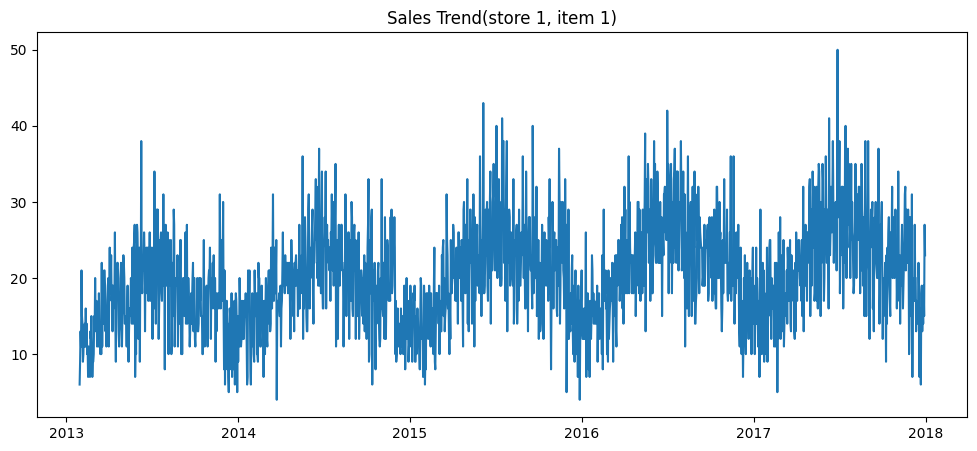

In [19]:
sample = df[(df["store"]==1) & (df["item"]==1)]

plt.figure(figsize=(12,5))
plt.plot(sample["date"],sample["sales"])
plt.title("Sales Trend(store 1, item 1)")
plt.show()

* data shows seasonality, trend and heteroscedasticity affecting model choice.

* This shows demand increases towards end of week.

* This show demand rises mid-year and falls at end of year.

* This show strong positive relationship. sales today depend heavily on sales 7 days ago.

In [24]:
drop_cols = ["week","year","month","diff_7"]

df = df.drop(columns=drop_cols)

In [25]:
print(df.columns)
print(df.shape)

Index(['date', 'store', 'item', 'sales', 'lag_1', 'lag_7', 'lag_14', 'lag_28',
       'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'rolling_std_7',
       'rolling_std_14', 'rolling_std_28', 'day_of_week', 'dow_sin', 'dow_cos',
       'month_sin', 'month_cos', 'trend', 'diff_1', 'roc_7', 'store_avg_sales',
       'item_avg_sales'],
      dtype='str')
(899000, 24)


In [26]:
df.isnull().sum()

date               0
store              0
item               0
sales              0
lag_1              0
lag_7              0
lag_14             0
lag_28             0
rolling_mean_7     0
rolling_mean_14    0
rolling_mean_28    0
rolling_std_7      0
rolling_std_14     0
rolling_std_28     0
day_of_week        0
dow_sin            0
dow_cos            0
month_sin          0
month_cos          0
trend              0
diff_1             0
roc_7              0
store_avg_sales    0
item_avg_sales     0
dtype: int64

In [27]:
df.to_csv("../data/Processed/Timeseries_cleaned.csv", index=False)